<a href="https://colab.research.google.com/github/kayurh/data_analytics/blob/main/1_2_lecture_Kayur_Amour_Harry.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Lesson 1 - Structured Data and DataFrame Handling 2.

- The goal of this lesson is to get familiar with the Pandas DataFrame concept and its usage.
- We will learn how to read, modify, and analyze data using a DataFrame.
- By the end of the lesson, students will be able to perform simple data manipulations in Python.

### The Iris dataset

The Iris dataset is a classic dataset in the world of machine learning and data analysis.
This dataset contains 150 flower samples belonging to three different iris species
(setosa, versicolor, virginica).

Each flower sample has four features:
- sepal.length (sepal length, cm)
- sepal.width (sepal width, cm)
- petal.length (petal length, cm)
- petal.width (petal width, cm)
- variety (the name of the iris species)


More details: https://archive.ics.uci.edu/dataset/53/iris

Loading Data

In [ ]:
import pandas as pd

# Reading the Iris dataset
df = pd.read_csv('https://gist.github.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv')

# Viewing the first 5 rows
display(df.head())



,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


### Basic column operations

Operations with columns help bring data into a more understandable form.

### Creating a New Column

For example, we can create a new column that is the product of sepal length and width:

In [ ]:
df["sepal.area"] = df["sepal.length"] * df["sepal.width"]
display(df.head())

,sepal.length,sepal.width,petal.length,petal.width,variety,sepal.area
0,5.1,3.5,1.4,0.2,Setosa,17.85
1,4.9,3.0,1.4,0.2,Setosa,14.70
2,4.7,3.2,1.3,0.2,Setosa,15.04
3,4.6,3.1,1.5,0.2,Setosa,14.26
4,5.0,3.6,1.4,0.2,Setosa,18.00


Why is this useful?
- Helps expand the data (for example, an area calculation).
- Can be used for further analysis.

### How lambda functions work in python

A lambda function is a one-line, anonymous function used for short, simple operations.

The syntax is:
- lambda parameters: expression

This function automatically returns a value, so there's no need for the return keyword.


### Simple Lambda Function Examples

Doubling with a lambda function

A traditional function:

In [ ]:
def double(x):
    return x * 2

print(double(5))  # Output: 10


10


The same with a lambda function:

In [ ]:
double = lambda x: x * 2
print(double(5))  # Output: 10


10


What happens here?
- lambda x: x * 2 is an anonymous function that takes an input value x
  and returns x * 2.

Adding two numbers

In [ ]:
add = lambda a, b: a + b  # expects two parameters (a, b) and returns their sum
print(add(3, 7))  # Output: 10


10


### Conditional Lambda Function
If we want to check whether a number is even or odd, we can do it with a lambda function:

In [ ]:
# A lambda function that determines whether a number is even or odd.
# Syntax: lambda input: expression
# In the expression, we use a conditional structure (if-else) here.
even_or_odd = lambda x: "Even" if x % 2 == 0 else "Odd"
# Explanation:
# - x % 2 == 0 → true if x is divisible by 2, i.e., even
# - if true → returns "Even" text
# - if false → returns "Odd" text

print(even_or_odd(4))  # Output: "Even"
print(even_or_odd(5))  # Output: "Odd"


Even
Odd


What does this do?
- If x is divisible by 2, the output will be "Even".
- If not, then "Odd".

### Lambda in pandas

Lambda functions are frequently used with Pandas DataFrames, especially with the apply() method.


### Transforming Every Element of a Column

We convert every element of sepal length from centimeters to millimeters.

In [ ]:
df["sepal.length_mm"] = df["sepal.length"].apply(lambda x: x * 10)
display(df.head())


,sepal.length,sepal.width,petal.length,petal.width,variety,sepal.area,sepal.length_mm
0,5.1,3.5,1.4,0.2,Setosa,17.85,51.0
1,4.9,3.0,1.4,0.2,Setosa,14.70,49.0
2,4.7,3.2,1.3,0.2,Setosa,15.04,47.0
3,4.6,3.1,1.5,0.2,Setosa,14.26,46.0
4,5.0,3.6,1.4,0.2,Setosa,18.00,50.0


What happens here?
- apply(lambda x: x * 10): The lambda function receives the x value (the sepal_length value)
  in each row and multiplies it by 10.
- We save the result in a new column (sepal_length_mm).

### Creating Categories Using Lambda
Based on sepal length, we want to categorize each sample as "Short" or "Long".

In [ ]:
df["sepal_category"] = df["sepal.length"].apply(lambda x: "Long" if x > df["sepal.length"].median() else "Short")
display(df.head())


,sepal.length,sepal.width,petal.length,petal.width,variety,sepal.area,sepal.length_mm,sepal_category
0,5.1,3.5,1.4,0.2,Setosa,17.85,51.0,Short
1,4.9,3.0,1.4,0.2,Setosa,14.70,49.0,Short
2,4.7,3.2,1.3,0.2,Setosa,15.04,47.0,Short
3,4.6,3.1,1.5,0.2,Setosa,14.26,46.0,Short
4,5.0,3.6,1.4,0.2,Setosa,18.00,50.0,Short


Why is this useful?
- We can create categories from numeric values.

### Using Multiple Columns Simultaneously
We add sepal and petal length into a new column.

In [ ]:
df["total_length"] = df.apply(lambda row: row["sepal.length"] + row["petal.length"], axis=1)
display(df.head())


,sepal.length,sepal.width,petal.length,petal.width,variety,sepal.area,sepal.length_mm,sepal_category,total_length
0,5.1,3.5,1.4,0.2,Setosa,17.85,51.0,Short,6.5
1,4.9,3.0,1.4,0.2,Setosa,14.70,49.0,Short,6.3
2,4.7,3.2,1.3,0.2,Setosa,15.04,47.0,Short,6.0
3,4.6,3.1,1.5,0.2,Setosa,14.26,46.0,Short,6.1
4,5.0,3.6,1.4,0.2,Setosa,18.00,50.0,Short,6.4


What happens here?
- apply() works on the entire column (axis=1).
- The lambda function adds the sepal.length and petal.length values.

### Conditional Modification (lambda and map())
We convert a numeric column to text values.

In [ ]:
# Creating a new column: 'variety_numeric'
# We convert the categories in the 'variety' column (text values) to numbers.
#
# .map() applies the lambda function to each element:
# - if the value is "Setosa", then 0
# - if "Versicolor", then 1
# - otherwise (meaning "Virginica") then 2
#
# This is a simple example of category encoding (label encoding).

df["variety_numeric"] = df["variety"].map(lambda x: 0 if x == "Setosa" else (1 if x == "Versicolor" else 2))
display(df[["variety", "variety_numeric"]].head())


,variety,variety_numeric
0,Setosa,0
1,Setosa,0
2,Setosa,0
3,Setosa,0
4,Setosa,0


What does this do?
- "Setosa" → 0
- "Versicolor" → 1
- "Virginica" → 2
- This can help in preparing data for machine learning models.

### Using the map() function

The map() function applies a function or rule to every element of a pandas **Series**.
This is very useful when we want to transform, modify, or encode every value.

**Example:**
- Original series: [1, 2, 3, 4, 5]
- map(lambda x: x * 10) → multiplies each element by 10
- Result: [10, 20, 30, 40, 50]

So map() works at the **element level** and transforms each value according to the given rule.
This can be a simple operation (multiplication, addition), or even conditional logic (if-else).

In [ ]:
# Simple series with numbers
series = pd.Series([1, 2, 3, 4, 5])

# map() applies a function to each element.
# Here: we multiply each number by 10.
new_series = series.map(lambda x: x * 10)

print("Original series:")
print(series)
print("\nTransformed series:")
print(new_series)

Original series:
0    1
1    2
2    3
3    4
4    5
dtype: int64

Transformed series:
0    10
1    20
2    30
3    40
4    50
dtype: int64


### The apply() function

apply() is more versatile than map().
- **On a Series** → works similarly to map(): applies the function to each element.
- **On a DataFrame** → can be applied to columns or rows.

**Important parameter:**
- axis=0 (default) → runs the function column-wise
- axis=1 → runs the function row-wise

**Examples:**
- df["A"].apply(lambda x: x**2) → squares each element in column A
- df.apply(sum, axis=0) → gives the sum of each column
- df.apply(sum, axis=1) → gives the sum of each row

apply() is very useful when we want to apply **our own function** to data,
either at the row or column level.

In [ ]:
# Small sample DataFrame
df_t = pd.DataFrame({
    "A": [1, 2, 3],
    "B": [10, 20, 30]
})

# apply() on a Series (similar to map)
df_t["A_squared"] = df_t["A"].apply(lambda x: x**2)

# apply() on a DataFrame
# axis=0 → applies the function to columns
column_sum = df_t.apply(sum, axis=0)

# axis=1 → applies the function to rows
row_sum = df_t.apply(sum, axis=1)

print("Column-wise sum:\n", column_sum)
print("\nRow-wise sum:\n", row_sum)


Column-wise sum:
 A             6
B            60
A_squared    14
dtype: int64

Row-wise sum:
 0    12
1    26
2    42
dtype: int64


.map() and .apply() are indeed similar, but there are important differences between them.

Difference between map() and apply() on Series


In [ ]:

new1 = series.map(lambda x: x * 10)    # works
new2 = series.apply(lambda x: x * 10)  # works


.map()
 - applies only to Series and runs the function at the element level.
 - simpler, faster when we want to transform each individual element.

.apply() → more general:
 - can be used on Series as well (then similar to .map()),
 - but can also be used on DataFrames, where you can apply a function
   to rows or columns (axis=0 / axis=1).

### Selecting all numeric columns

In [ ]:
# Selecting numeric columns
numeric_columns = df.select_dtypes(include=["number"]).columns
numeric_columns


Index(['sepal.length', 'sepal.width', 'petal.length', 'petal.width',
       'sepal.area', 'sepal.length_mm', 'total_length', 'variety_numeric'],
      dtype='object')

### Selecting Non-Numeric Columns

If we want to get the columns that are not numeric:

In [ ]:
non_numeric_columns = df.select_dtypes(exclude=["number"]).columns
non_numeric_columns


Index(['variety', 'sepal_category'], dtype='object')

### Processing categories and text data

Although the Iris dataset mostly contains numeric data,
there is one categorical column (variety) that should be properly processed.

In [ ]:
print(df["variety"].value_counts())


variety
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


Why is this important?
- Shows the proportion of each category.

### Encoding Categories with Numeric Values
Machine learning models cannot work with text categories,
so they need to be converted to numeric.

Label Encoding (simple numbering)

In [ ]:
df["variety_encoded"] = df["variety"].astype("category").cat.codes
display(df[["variety", "variety_encoded"]].head())

,variety,variety_encoded
0,Setosa,0
1,Setosa,0
2,Setosa,0
3,Setosa,0
4,Setosa,0


Why is this important?
- If a column contains a few categories, this is a simple solution.

One-Hot Encoding (dummy variables)

In [ ]:
df = pd.get_dummies(df, columns=["variety"])
display(df.head())

,sepal.length,sepal.width,petal.length,petal.width,sepal.area,sepal.length_mm,sepal_category,total_length,variety_numeric,variety_encoded,variety_Setosa,variety_Versicolor,variety_Virginica
0,5.1,3.5,1.4,0.2,17.85,51.0,Rövid,6.5,0,0,True,False,False
1,4.9,3.0,1.4,0.2,14.70,49.0,Rövid,6.3,0,0,True,False,False
2,4.7,3.2,1.3,0.2,15.04,47.0,Rövid,6.0,0,0,True,False,False
3,4.6,3.1,1.5,0.2,14.26,46.0,Rövid,6.1,0,0,True,False,False
4,5.0,3.6,1.4,0.2,18.00,50.0,Rövid,6.4,0,0,True,False,False


Why is this important?
- This helps avoid models incorrectly assuming an ordinal relationship between categories.

### Data visualization basics

The purpose of data visualization:
- Helps reveal the structure and patterns in data.
- Highlights anomalies and trends.
- Makes comparison and analysis easier.

What types of charts do we use?
- Matplotlib – Basic plotting (histogram, scatter plot, line chart)
- Seaborn – Statistical analysis (boxplot, heatmap, pairplot)


### What is a histogram?

A histogram is a diagram that shows
how frequently the values of a numeric variable occur
in different value ranges.

The value range is divided into smaller intervals (called *bins*),
and each bar shows how many data points fall into that range.

With a histogram, we can:
- get an overview of the data distribution,
- recognize where values are concentrated,
- notice extreme (rare) values.

Important:
- the number of bars (*bins*) affects the detail of the diagram,
- too few bins lose details,
- too many bins can make the chart noisy.


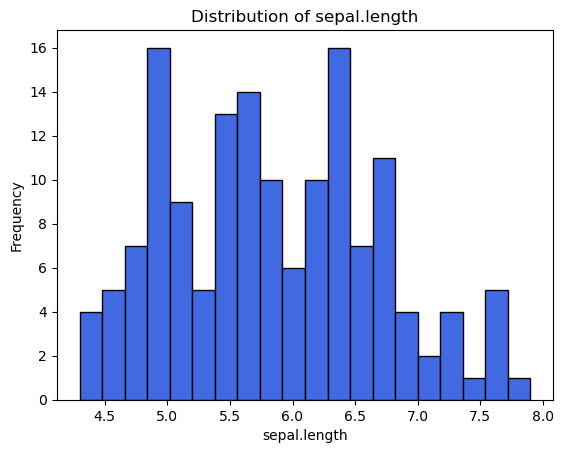

In [ ]:
import matplotlib.pyplot as plt  # We use the matplotlib library for data visualization.

# The histogram shows the distribution: how many samples are in different
# value ranges (so-called "bins").
# bins=20 -> we divide the values into 20 bars, giving us a more detailed picture.
# color and edgecolor -> we set the color of the bars and the border
plt.hist(df["sepal.length"], bins=20, color="royalblue", edgecolor="black")

# The axis labels help understand what the chart shows.
plt.xlabel("sepal.length")
plt.ylabel("Frequency")

# We also give a title to the chart so it's immediately clear what we're seeing.
plt.title("Distribution of sepal.length")

# Finally, the plt.show() call displays the diagram on the screen.
plt.show()

What does this chart show?

This histogram shows the **distribution** of the `sepal.length` variable.

- The **x-axis** marks the values of `sepal.length`.
- The **y-axis** shows the frequency,
  i.e., how many data points fall into the given range.
- Each bar represents a value range (bin).

Observations:
- Most data points are approximately between **5–6.5 cm**.
- Very small and very large values occur less frequently.
- The distribution is not completely uniform.

Interpretation:
The histogram helps get a quick picture of
how the data is distributed,
and which value ranges are most characteristic in the sample.

### What is kde (kernel density estimation)?

KDE (Kernel Density Estimation) is a method that estimates the **distribution
of a numeric variable in a continuous form**.

Simply put:
- it doesn't draw bars (like a histogram),
- but a **smoothed curve** that shows
  how **densely** the given values occur.

The purpose of KDE:
- to illustrate the **shape of the data distribution**,
- to show where there are "more frequent" and "less frequent" values.

Important:
- KDE is **not an exact measurement**, but an estimate,
- its shape depends on the degree of smoothing,
- it's primarily used for **visual analysis**.


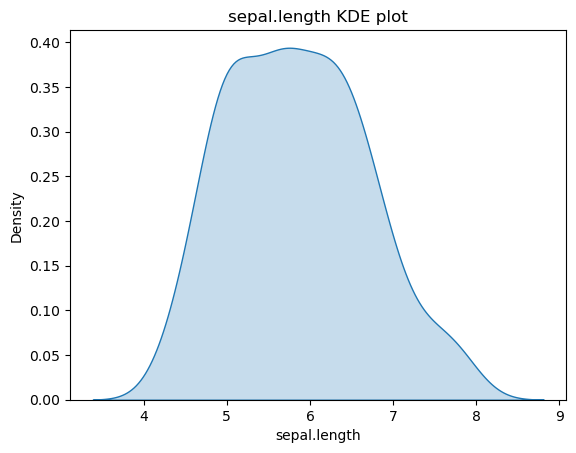

In [ ]:
import seaborn as sns

sns.kdeplot(df["sepal.length"], fill=True)
plt.xlabel("sepal.length")
plt.ylabel("Density")
plt.title("sepal.length KDE plot")
plt.show()


What does this chart show?

This chart shows the **density distribution** of the `sepal.length` variable using KDE.

- The **x-axis** shows the values of `sepal.length`.
- The **y-axis** indicates density (not count).
- The curve shows
  around which values the data is most concentrated.

Observations:
- Most values are located approximately between **5–6 cm**.
- The distribution is not completely symmetrical.
- Very small and very large values are rarer.

Interpretation:
This chart helps quickly understand
how the `sepal.length` variable is distributed in the sample,
without performing exact calculations.


### What is a scatter plot?

A scatter plot is a chart that
illustrates the **relationship** between two numeric variables.

Each point:
- represents an observation,
- on the x-axis is the value of one variable,
- on the y-axis is the value of the other variable.

With a scatter plot, we can:
- recognize if there is a relationship between the two variables,
- observe the distribution of data in space,
- notice any outliers.

Important:
- a scatter plot **does not prove a causal relationship**,
- it only shows co-variation (correlation pattern).


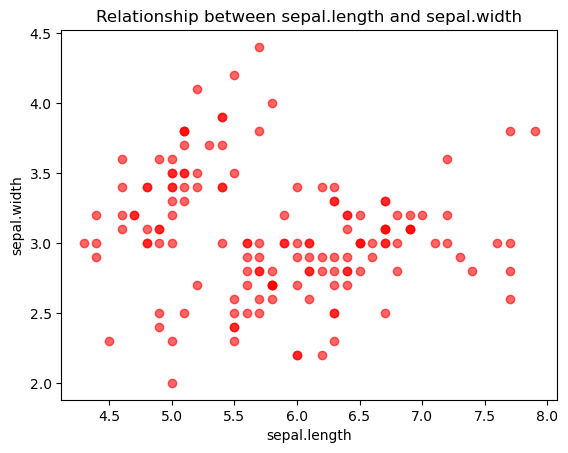

In [ ]:
# The scatter plot shows the relationship between two numeric variables.

# color="red" -> we draw the points in red.
# alpha=0.6 -> transparency setting (0=transparent, 1=fully opaque)
plt.scatter(df["sepal.length"], df["sepal.width"], color="red", alpha=0.6)

# Axis labels for understanding the variables
plt.xlabel("sepal.length")
plt.ylabel("sepal.width")

# Title for the chart so it's clear what we're showing
plt.title("Relationship between sepal.length and sepal.width")

# Display the chart
plt.show()

What does this chart show?

This scatter plot shows the relationship between `sepal.length`
and `sepal.width` variables.

- The **x-axis** shows the values of `sepal.length`.
- The **y-axis** shows the values of `sepal.width`.
- Each red point represents a flower (an observation).

Observations:
- The data points don't clearly lie along a single line.
- There are visible clusters where many points are concentrated.
- The relationship doesn't appear to be a strong linear relationship.

Interpretation:
This chart helps quickly assess
whether there is a visible relationship between the two variables,
and what the distribution of data is like in two-dimensional space.


### Creating a multivariate scatter plot (x, y, color, shape)

The scatter plot is one of the best tools for examining multiple variables together,
as we can display both numeric and categorical data at once in the following ways:

- X-axis -> A numeric variable (e.g., sepal.length)
- Y-axis -> Another numeric variable (e.g., sepal.width)
- Color -> Categorical variable (e.g., variety_numeric)
- Shape (marker or style) -> Another categorical variable or numeric group
- Example: Let's examine the relationship between sepal.length, sepal.width,
  and variety_numeric on a scatter plot!


Let's examine the following variables:
- X-axis: sepal.length
- Y-axis: sepal.width
- Color: variety_numeric



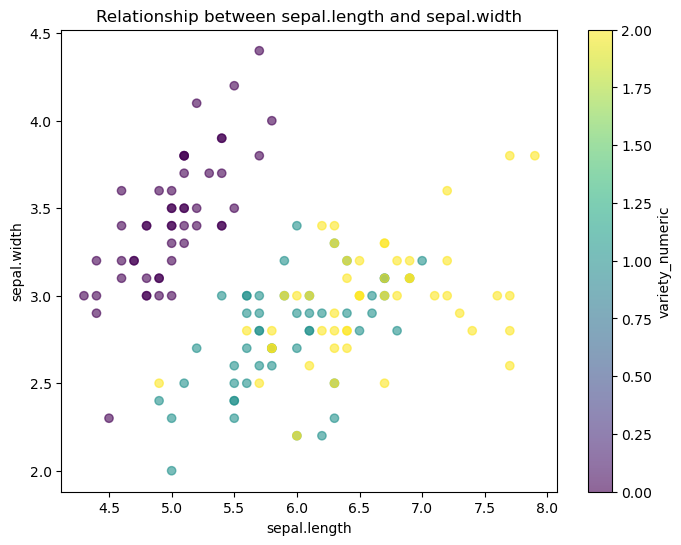

In [ ]:
# Creating a scatter plot for the relationship between alcohol and color intensity
# Creating a scatter plot
plt.figure(figsize=(8,6))
scatter = plt.scatter(
                        df["sepal.length"],
                        df["sepal.width"],
                        c=df['variety_numeric'],      # use 'c' for continuous color
                        cmap='viridis',           # color scale
                        alpha=0.6
                    )

plt.xlabel("sepal.length")
plt.ylabel("sepal.width")
plt.title("Relationship between sepal.length and sepal.width")

# Adding a color bar
cbar = plt.colorbar(scatter)
cbar.set_label('variety_numeric')

plt.show()

What do we see in the chart?

The chart shows the relationship between *sepal.length* and *sepal.width* on a scatter plot.
Each point represents a flower sample, and the color of the points distinguishes
the iris species based on the **variety_numeric** variable.

The diagram clearly shows that the data form several, partially separated groups,
suggesting that the sepal dimensions are related to the species.
The scatter plot shows co-variation, not causal relationship,
and is one of the basic tools for exploratory data analysis.


### Kde plot of multiple variables for comparison

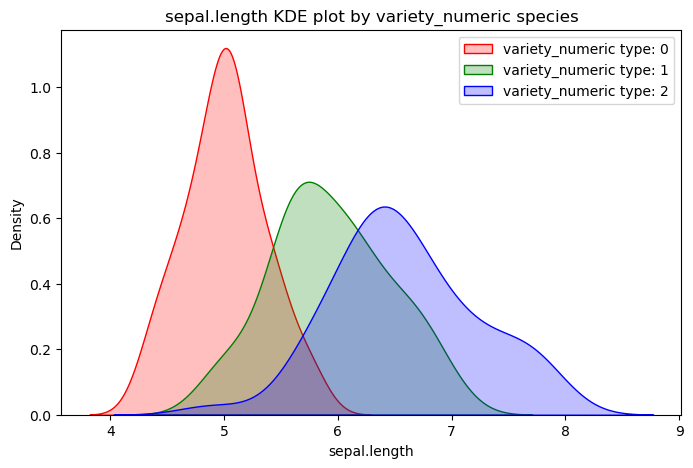

In [ ]:
plt.figure(figsize=(8, 5))
sns.kdeplot(df[df["variety_numeric"] == 0]["sepal.length"], fill=True, label="variety_numeric type: 0", color="red")
sns.kdeplot(df[df["variety_numeric"] == 1]["sepal.length"], fill=True, label="variety_numeric type: 1", color="green")
sns.kdeplot(df[df["variety_numeric"] == 2]["sepal.length"], fill=True, label="variety_numeric type: 2", color="blue")
plt.xlabel("sepal.length")
plt.ylabel("Density")
plt.title("sepal.length KDE plot by variety_numeric species")
plt.legend()
plt.show()


What do we see in the chart?

The chart shows the distribution of *sepal.length* with **KDE curves**
according to the different *variety_numeric* categories.
The curves represent the **density** of values belonging to each species,
making the shape, center, and overlap of distributions easily comparable.

The KDE plot helps recognize which groups are well separated
and where there are overlaps between distributions.

### Exercises
Let's load the TITANIC dataset


In [1]:
# Loading Titanic data using Scikit-learn

from sklearn.datasets import fetch_openml
import pandas as pd

# Loading data from the OpenML database
titanic = fetch_openml(name="titanic", version=1, as_frame=True)

# Converting data to Pandas DataFrame format
df = titanic.data
df["survived"] = titanic.target  # We also assign the target variable (y)

### Exercise 1

Create a new column named age_group:
- "child": age < 18
- "adult": 18 ≤ age < 60
- "senior": age ≥ 60

Handle missing ages separately (e.g., "unknown").

Count how many passengers belong to each age group.
(Hint: apply() + lambda)

In [2]:
df['age_group'] = df['age'].apply(lambda x: 'unknown' if pd.isna(x) else ('child' if x < 18 else ('adult' if x < 60 else 'senior')))
print(df['age_group'].value_counts())


age_group
adult      852
unknown    263
child      154
senior      40
Name: count, dtype: int64


### Exercise 2

Convert the sex column to numeric form using map().
Convert the embarked column:
- once using cat.codes,
- once using one-hot encoding.

Compare:
which encoding would be more suitable for data analysis or modeling?

(Hint: map(), astype("category"), get_dummies())

In [3]:
df['sex_numeric'] = df['sex'].map({'male': 0, 'female': 1})
df['embarked_cat'] = df['embarked'].astype('category')
df['embarked_codes'] = df['embarked_cat'].cat.codes
df = pd.get_dummies(df, columns=['embarked'])

### Exercise 3

Create a histogram of the age variable.
Create a KDE plot of the age variable:
- separately for survivors (survived = 1)
- and non-survivors (survived = 0).

Briefly describe: what is the difference between the two distributions?

(Hint: hist(), sns.kdeplot())

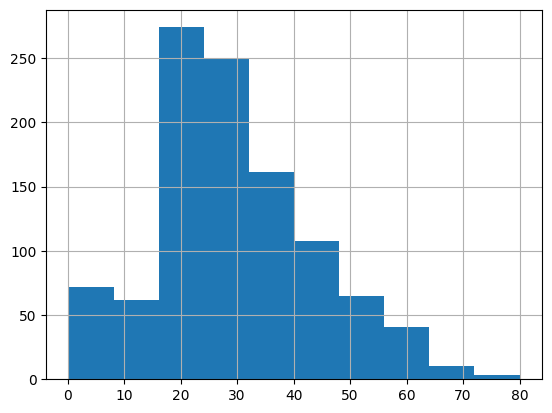

/tmp/ipykernel_810/2915511831.py:8: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df[df['survived'] == 1], x='age')
/tmp/ipykernel_810/2915511831.py:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df[df['survived'] == 0], x='age')


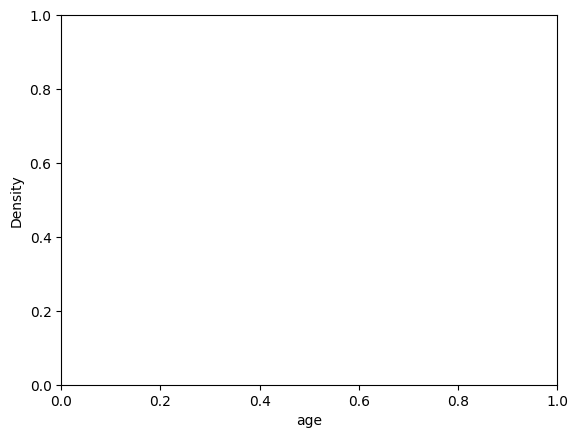

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
df['age'].hist()
plt.show()

sns.kdeplot(data=df[df['survived'] == 1], x='age')
sns.kdeplot(data=df[df['survived'] == 0], x='age')
plt.show()


### Exercise 4

Create a scatter plot:
- fare on the x-axis,
- age on the y-axis.

Color the points based on the survived variable.

Examine:
- is there a visible relationship between ticket price, age, and survival?
- are there any outliers?

(Hint: plt.scatter(), c= parameter)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml

plt.scatter(df['fare'], df['age'], c=df['survived'])
plt.show()

### +1 Extra Exercise – Creating and Examining a New Feature

Create a new column named family_size using the following formula:
- family_size = sibsp + parch + 1

Create a new category variable named family_type using apply() and lambda:
- "alone": family_size = 1
- "small_family": 2 ≤ family_size ≤ 4
- "large_family": family_size ≥ 5

Count:
- how many passengers belong to each family_type category
(Hint: value_counts())

Create:
- a histogram of the family_size variable,
- a KDE plot of the family_size variable colored by survival (survived).

(Tools used: lambda, apply, value_counts, hist, kdeplot)

family_type
alone           790
small_family    437
large_family     82
Name: count, dtype: int64


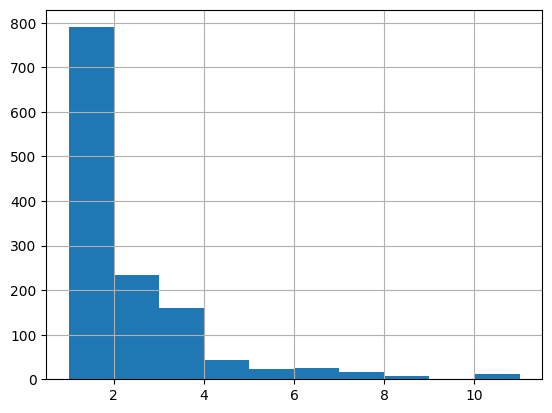

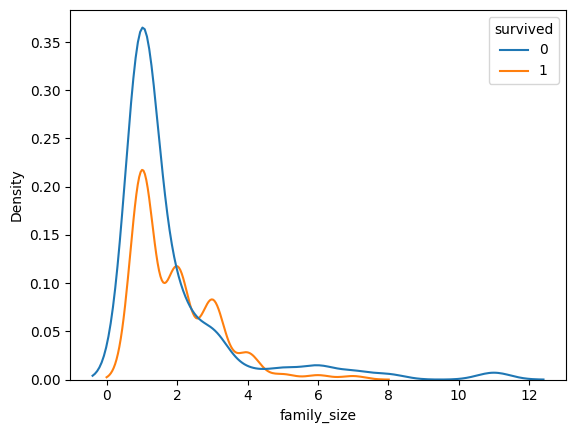

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml

df['family_size'] = df['sibsp'] + df['parch'] + 1
df['family_type'] = df['family_size'].apply(lambda x: 'alone' if x == 1 else ('small_family' if x <= 4 else 'large_family'))

print(df['family_type'].value_counts())

df['family_size'].hist()
plt.show()

sns.kdeplot(data=df, x='family_size', hue='survived')
plt.show()